In [1]:
# Setup and imports
%matplotlib inline
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt
import os

print("✓ All imports successful")

✓ All imports successful


In [2]:
# Load the .bcf file
bcf_file = os.path.expanduser("~/sierra_nevada/uXRF/25KC-19.bcf")

print(f"Loading: {bcf_file}")
s = hs.load(bcf_file)

print(f"✓ File loaded successfully!")
print(f"Data shape: {s.data.shape}")
print(f"Data type: {type(s)}")
print(f"\nMetadata:")
print(s.metadata)

Loading: /Users/dhasterok/sierra_nevada/uXRF/25KC-19.bcf
WARNING | Hyperspy | `signal_type='EDS_SEM'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)
✓ File loaded successfully!
Data shape: (2018, 2029, 4096)
Data type: <class 'hyperspy._signals.signal1d.Signal1D'>

Metadata:
├── Acquisition_instrument
│   └── SEM
│       ├── Detector
│       │   └── EDS
│       │       ├── detector_type = XFlash 660 XMA
│       │       ├── elevation_angle = 50.0
│       │       └── real_time = 16386.203999999998
│       ├── Stage
│       │   ├── x = 196.597
│       │   ├── y = 135.965
│       │   └── z = 67.273
│       └── beam_energy = 50
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.3.0
│   │       ├── io_plugin = rsciio.bruker
│   │       ├── operation = load
│   │       └── timestamp = 2025-12-1

WARNING | Hyperspy | `signal_type='EDS_SEM'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)
WARNING | Hyperspy | `signal_type='EDS_SEM'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)


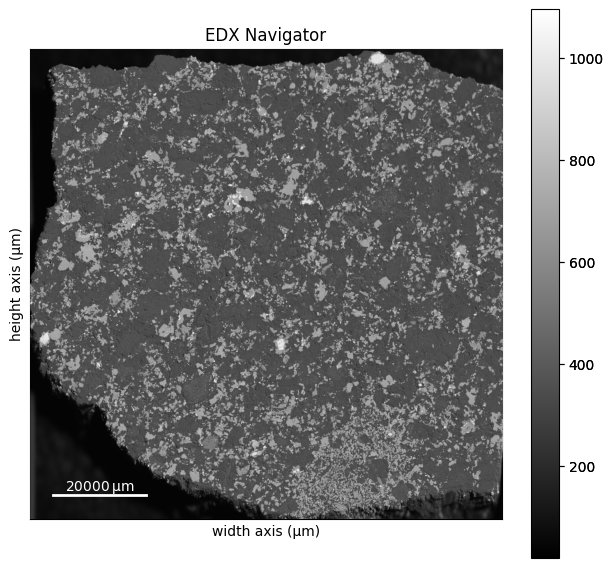

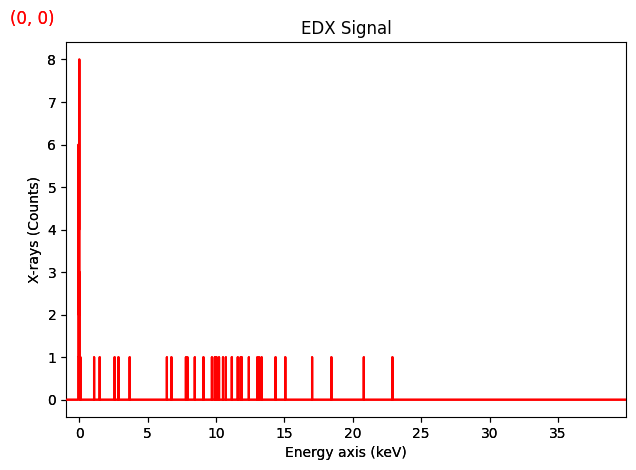

In [3]:
# View the spectrum image interactively
# This opens an interactive viewer with navigation and energy spectrum
s.plot()

In [4]:
# Get element maps from the data
# This extracts elemental information if available in the .bcf metadata
elements = s.metadata.Sample.elements if hasattr(s.metadata, 'Sample') else []
print(f"Elements detected: {elements}")

# You can also check the energy range
if hasattr(s, 'axes_manager'):
    energy_axis = s.axes_manager.signal_axes[0]
    print(f"\nEnergy range: {energy_axis.offset:.2f} to {energy_axis.offset + energy_axis.size * energy_axis.scale:.2f} keV")
    print(f"Energy resolution: {energy_axis.scale:.4f} keV/channel")

Elements detected: []

Energy range: -0.95 to 40.01 keV
Energy resolution: 0.0100 keV/channel


Text(29.000000000000007, 0.5, 'Counts')

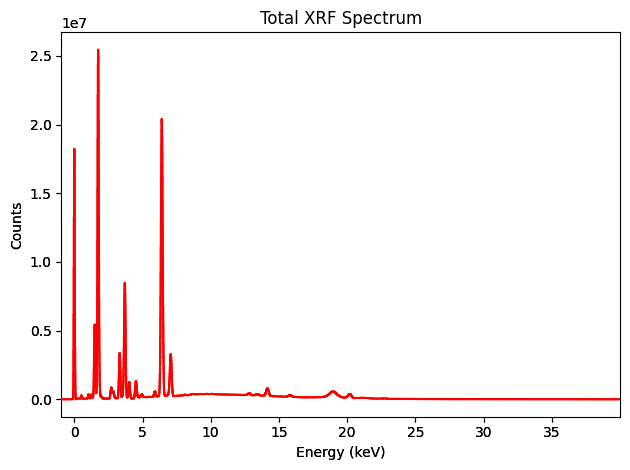

In [5]:
# Sum the spectrum across all pixels to get a total spectrum
total_spectrum = s.sum()
total_spectrum.plot()
plt.title("Total XRF Spectrum")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")

## Basic Processing Operations

Below are some common operations for processing XRF data:

WARNING | Hyperspy | `signal_type='EDS_SEM'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)
WARNING | Hyperspy | `signal_type='EDS_SEM'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)


Text(0.5, 0.98, 'Elemental Map (6.0-7.0 keV)')

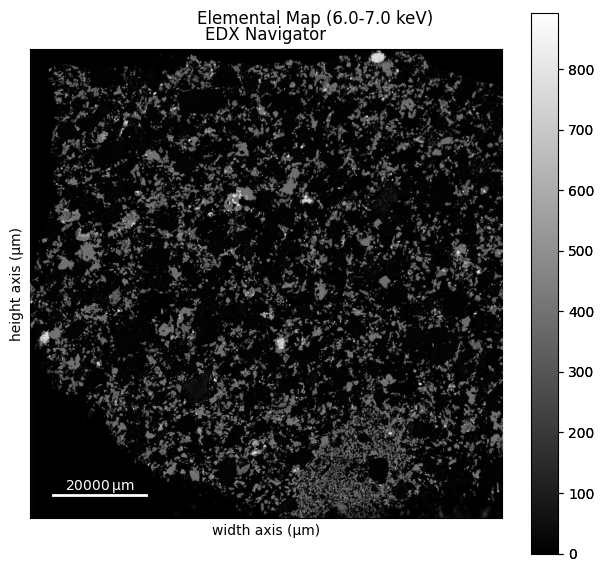

In [6]:
# Create an elemental map by integrating over a specific energy window
# Example: Create a map for a specific element (adjust energy range as needed)
energy_min = 6.0  # keV
energy_max = 7.0  # keV

# Get the spectrum for a specific energy range
element_map = s.isig[energy_min:energy_max].sum(axis=-1)

# Plot the elemental map (HyperSpy's plot includes colorbar automatically)
element_map.plot()
# Optional: add a title to the current figure
plt.gcf().suptitle(f"Elemental Map ({energy_min}-{energy_max} keV)")

Removing background from total spectrum...


The inline matplotlib backend is not compatible with the traitsui GUI elements. For more information, read https://hyperspy.readthedocs.io/en/stable/user_guide/basic_usage.html#possible-warnings-when-importing-hyperspy.
/Users/dhasterok/GitHub/LaserMapExplorer/.venv/lib/python3.11/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


AttributeError: 'NoneType' object has no attribute 'plot'

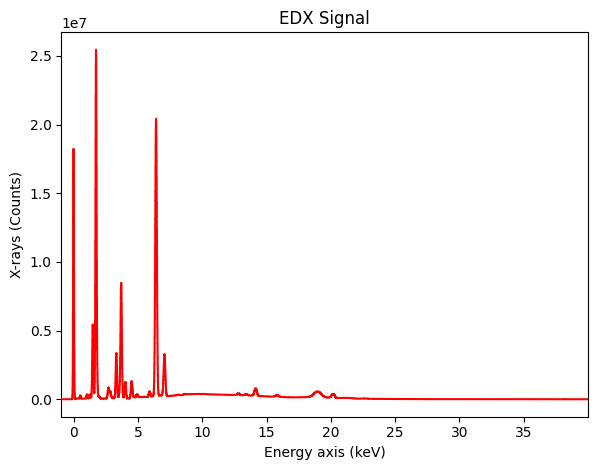

In [7]:
# Background removal - simplified approach
# Remove background from the summed spectrum first (faster)
print("Removing background from total spectrum...")
total_spectrum_bg = s.sum().remove_background()
total_spectrum_bg.plot()
plt.title("Total Spectrum - Background Removed")

## Automatic Element Identification

HyperSpy can automatically identify elements and create models for each element's characteristic X-ray lines:

In [ ]:
# Add elements to the model
# You can specify elements manually or use auto-detection
# Example: manually add common rock-forming elements
elements_to_add = ['Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ti', 'Fe', 'P', 'Cu', 'Zn', 'Mn', 'Cr', 'Ni', 'Co', 'Sr', 'Ba', 'U', 'Th', 'Rb', 'Zr', 'Y', 'V', 'Sc', 'Cs', 'La', 'Ce', 'Nd', 'Sm', 'Eu', 'Gd']

# Set the elements and X-ray lines
s.set_elements(elements_to_add)
s.set_lines(elements_to_add)

print(f"Added elements: {s.metadata.Sample.elements}")
print(f"X-ray lines: {s.metadata.Sample.xray_lines}")

In [ ]:
# Create a model with all the elements
# This creates a model that accounts for overlapping peaks
print("Creating EDS/XRF model...")
m = s.create_model()

print(f"Model created with {len(m)} components")
print("\nModel components:")
for component in m:
    print(f"  - {component.name}")

In [ ]:
# Fit the model to estimate element intensities
# This will fit the model and handle overlapping peaks
print("Fitting model (this may take a few minutes for large datasets)...")
m.fit()

# Plot the fitted model
m.plot()
plt.title("Model Fit with Element Deconvolution")

In [ ]:
# Get intensity maps for each element
# This extracts the intensity for each element from the fitted model
print("Extracting element intensity maps...")
intensity_maps = m.get_lines_intensity()

# Plot intensity maps for all elements
n_elements = len(intensity_maps)
n_cols = 3
n_rows = (n_elements + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, (element_line, intensity_map) in enumerate(intensity_maps):
    ax = axes[i]
    im = ax.imshow(intensity_map.data, cmap='viridis')
    ax.set_title(f"{element_line}")
    plt.colorbar(im, ax=ax)
    ax.axis('off')

# Hide unused subplots
for i in range(n_elements, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Element Intensity Maps from Model", y=1.001)

## Alternative: Automatic Peak Finding

If you want to automatically detect which elements are present:

In [ ]:
# Auto-detect elements from peaks in the summed spectrum
# This is useful when you don't know what elements are present
total = s.sum()

# Find peaks automatically
peaks = total.find_peaks1D_ohaver()
print(f"Found {len(peaks)} peaks")

# You can then manually inspect the peak positions and match to elements
# Or use HyperSpy's element identification
# Uncomment to see peak positions:
# print("Peak positions (keV):", peaks)

In [ ]:
# Export data for further analysis
# Save as HDF5 format (preserves all metadata)
# s.save("processed_data.hdf5")

# Or export elemental maps as images
# element_map.save("element_map.png")